### Building a CNN Architecture in keras
* Steps to build CNN
    * Convolutional Layers: Extract Features from the input images
    * Pooling Layers : Downsample feature maps to reduce dimensions and retain key features
    * Dense (Fully Connected Layers): Combine features for final predictions
* Basic CNN Arch:
    * Input Layer -> Conv Layer -> Activation Layer -> Fully Connected Layers -> Output Layers
    * Repeat the conv layer and pooling layer

* Compiling , Training and Evaluation Layer
    *  Steps:
        * Compile the model
            * Define loss, optimizer and metrics
            * Example loss function
                * Categorical Cross- Entropy: Multi Class Classifcation
            * Example Optimizers:
                * Adam:: Efficient Optimization for large networks
            * Example metrics: Accuracy

        * Train the model
            * Use model.fit() with training data , validation daata, epochs and batch size
        * Evaluate the model
            * use model.evaluate()

### Introduction to Popular CNN Architecture
* LeNet
    * One of the earliest CNNs for handwritten digit classification (Eg: MNIST)
* ALexNet
    * Revolutionzed deep learning for image classification in 2012
    * introduced ReLU activation and dropout for reguilarization
* VGG
    * Uses deep network with small filters (eg: 3x3)
    * Known for its simplicity and effectivness
    

In [6]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, Input


In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 57s 0us/step


In [4]:
# Normalize the data
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One Hot Encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (50000, 32, 32, 3)
X_test shape: (10000, 32, 32, 3)
y_train shape: (50000, 10)
y_test shape: (10000, 10)


In [7]:
# Build the model
model = Sequential([
    Input(shape=(32,32,3)),
    Conv2D(32,(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7053 - loss: 0.8238 - val_accuracy: 0.7066 - val_loss: 0.8472
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7173 - loss: 0.7844 - val_accuracy: 0.7037 - val_loss: 0.8784
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7240 - loss: 0.7648 - val_accuracy: 0.7126 - val_loss: 0.8539
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7355 - loss: 0.7311 - val_accuracy: 0.7209 - val_loss: 0.8511
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7422 - loss: 0.7123 - val_accuracy: 0.7144 - val_loss: 0.8512
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7503 - loss: 0.6848 - val_accuracy: 0.7087 - val_loss: 0.8704
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7599 - loss: 0.6580 - val_accuracy: 0.7168 - val_loss: 0.8753
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7663 - loss: 0.6377 - val_accuracy: 0.

In [14]:
# Evaluate on the test datasets
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7050 - loss: 1.1089
Test Loss: 1.1089340448379517
Test Accuracy: 0.7049999833106995


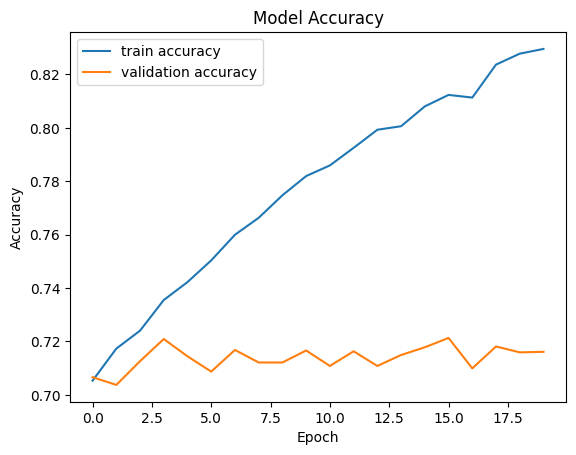

In [15]:
import matplotlib.pyplot as plt

# plot accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


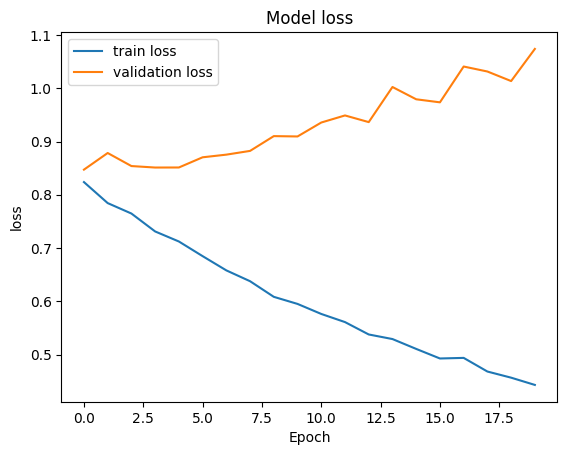

In [16]:
# plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.show()